# Librerias

In [36]:
import numpy as np
import matplotlib.pyplot as plt

In [16]:
np.random.seed(42)

# Desvanecimiento y explosión del gradiente

Durante el entrenamiento de una red neuronal profunda, el gradiente de la función de pérdida respecto a las capas iniciales se obtiene como el producto sucesivo de derivadas parciales asociadas a las capas posteriores.

Si $\mathcal{L}$ es la función de pérdida y $h^{(l)}$ representa la salida de la capa $l$, entonces el gradiente respecto a una capa intermedia puede escribirse de manera esquemática como

$$
\frac{\partial \mathcal{L}}{\partial h^{(l)}}=
\frac{\partial \mathcal{L}}{\partial h^{(L)}}
\prod_{k=l+1}^{L}
\frac{\partial h^{(k)}}{\partial h^{(k-1)}}.
$$

Esto muestra que el gradiente depende de un producto de muchas matrices Jacobianas o derivadas. Cuando la red tiene muchas capas, este producto puede comportarse de dos maneras:

- si los factores tienen norma típica menor que 1, el producto tiende a 0;
- si los factores tienen norma típica mayor que 1, el producto crece rápidamente.

---

Desvanecimiento del gradiente

Se dice que ocurre **desvanecimiento del gradiente** cuando las derivadas que aparecen en la retropropagación son suficientemente pequeñas y, al multiplicarse repetidamente, producen gradientes cercanos a cero.

Es decir, si repetimos una multiplicación por un número menor que 1, por ejemplo:

$$
0.5^{20} \approx 9.54 \times 10^{-7},
$$

el resultado se vuelve prácticamente nulo.

En redes neuronales esto implica que las primeras capas reciben señales de actualización extremadamente pequeñas, por lo que sus pesos apenas cambian durante el entrenamiento. Como consecuencia, la red aprende muy lentamente o incluso deja de aprender en sus capas profundas.

---

Explosión del gradiente

Se dice que ocurre **explosión del gradiente** cuando las derivadas y transformaciones lineales acumuladas en la retropropagación producen gradientes extremadamente grandes.

Por ejemplo, si repetimos una multiplicación por un número mayor que 1:

$$
1.5^{20} \approx 3325,
$$

el resultado crece rápidamente.

En una red neuronal, esto puede provocar:

- actualizaciones demasiado grandes en los pesos
- inestabilidad numérica
- divergencia del entrenamiento
- aparición de valores infinitos o `NaN`

In [17]:
# Funciones de activación

def sigmoid(Z):
    return 1 / (1 + np.exp(-Z))

def sigmoid_backward(A):
    return A * (1 - A)

def tanh(Z):
    return np.tanh(Z)

def tanh_backward(A):
    return 1 - A**2

def relu(Z):
    return np.maximum(0, Z)

def relu_backward(Z):
    return (Z > 0).astype(float)

In [18]:
# Pérdida MSE
def mse_loss(Y_hat, Y):
    return np.mean((Y_hat - Y)**2)

def mse_grad(Y_hat, Y):
    return 2 * (Y_hat - Y) / Y.shape[0]

In [19]:
# Inicialización arbitraria
def init_params_random(layer_dims, scale=1.0):
    params = {}
    L = len(layer_dims) - 1
    for l in range(1, L + 1):
        params[f"W{l}"] = scale * np.random.randn(layer_dims[l-1], layer_dims[l])
        params[f"b{l}"] = np.zeros((1, layer_dims[l]))
    return params

In [20]:
# Forward
def forward_pass(X, params, activation="sigmoid"):
    caches = []
    A = X
    L = len(params) // 2

    for l in range(1, L):
        W = params[f"W{l}"]
        b = params[f"b{l}"]
        Z = A @ W + b

        if activation == "sigmoid":
            A_next = sigmoid(Z)
        elif activation == "tanh":
            A_next = tanh(Z)
        elif activation == "relu":
            A_next = relu(Z)
        else:
            raise ValueError("Activación no soportada")

        caches.append((A, Z, A_next, W, b))
        A = A_next

    # última capa lineal
    W = params[f"W{L}"]
    b = params[f"b{L}"]
    Y_hat = A @ W + b
    caches.append((A, None, Y_hat, W, b))

    return Y_hat, caches

In [21]:
# Backward
def backward_pass(Y_hat, Y, caches, activation="sigmoid"):
    grads = {}
    L = len(caches)

    # salida lineal + MSE
    A_prev, _, _, W_last, _ = caches[-1]
    dZ = mse_grad(Y_hat, Y)  # como la última capa es lineal, dZ = dY_hat

    grads[f"dW{L}"] = A_prev.T @ dZ
    grads[f"db{L}"] = np.sum(dZ, axis=0, keepdims=True)
    dA_prev = dZ @ W_last.T

    # capas ocultas
    for l in reversed(range(L - 1)):
        A_prev, Z, A, W, b = caches[l]

        if activation == "sigmoid":
            dZ = dA_prev * sigmoid_backward(A)
        elif activation == "tanh":
            dZ = dA_prev * tanh_backward(A)
        elif activation == "relu":
            dZ = dA_prev * relu_backward(Z)
        else:
            raise ValueError("Activación no soportada")

        grads[f"dW{l+1}"] = A_prev.T @ dZ
        grads[f"db{l+1}"] = np.sum(dZ, axis=0, keepdims=True)
        dA_prev = dZ @ W.T

    return grads

In [22]:
# Norma del gradiente por capa
def grad_norms(grads, L):
    norms = []
    for l in range(1, L + 1):
        norms.append(np.linalg.norm(grads[f"dW{l}"]))
    return norms

In [23]:
# Datos
n_samples = 128
input_dim = 50
output_dim = 1

X = np.random.randn(n_samples, input_dim)
Y = np.random.randn(n_samples, output_dim)

# Red profunda
layer_dims = [50, 100, 100, 100, 100, 100, 100, 100, 100, 100, 1]
L = len(layer_dims) - 1

Pesos pequeños 

In [24]:
params_small = init_params_random(layer_dims, scale=0.01)
Y_hat_small, caches_small = forward_pass(X, params_small, activation="sigmoid")
grads_small = backward_pass(Y_hat_small, Y, caches_small, activation="sigmoid")
norms_small = grad_norms(grads_small, L)

print("Normas de gradiente con pesos pequeños:")
for i, n in enumerate(norms_small, 1):
    print(f"Capa {i}: {n:.6e}")

Normas de gradiente con pesos pequeños:
Capa 1: 3.799573e-15
Capa 2: 1.366557e-13
Capa 3: 5.107693e-12
Capa 4: 2.112773e-10
Capa 5: 8.477584e-09
Capa 6: 3.821273e-07
Capa 7: 1.769769e-05
Capa 8: 6.549557e-04
Capa 9: 2.598597e-02
Capa 10: 1.224813e+00


En el caso de la red con pesos inicializados con una escala muy pequeña, las normas de los gradientes en las primeras capas fueron reducidas, alcanzando valores del orden de $10^{(−15)}$,$10^(−13)$, $10^(−12)$ y así. Esto indica desvanecimiento del gradiente, ya que al retropropagarse el error a través de muchas capas, las derivadas sucesivas reducen su magnitud. Entonces, las capas iniciales reciben actualizaciones prácticamente nulas, lo que impide que aprendan de mejor manera. Aunque las últimas capas aún presentan gradientes de mayor tamaño, las primeras quedan casi “congeladas”, lo cual dificulta el entrenamiento de la red.

Pesos grandes

In [25]:
params_large = init_params_random(layer_dims, scale=3.0)
Y_hat_large, caches_large = forward_pass(X, params_large, activation="tanh")
grads_large = backward_pass(Y_hat_large, Y, caches_large, activation="tanh")
norms_large = grad_norms(grads_large, L)

print("Normas de gradiente con pesos grandes:")
for i, n in enumerate(norms_large, 1):
    print(f"Capa {i}: {n:.6e}")

Normas de gradiente con pesos grandes:
Capa 1: 6.230768e+06
Capa 2: 2.467705e+06
Capa 3: 5.660554e+05
Capa 4: 1.538788e+05
Capa 5: 5.406430e+04
Capa 6: 1.068902e+04
Capa 7: 3.626102e+03
Capa 8: 8.105159e+02
Capa 9: 2.701145e+02
Capa 10: 9.179088e+01


En el caso de la red con pesos inicializados con una escala muy grande, las normas de los gradientes en las primeras capas alcanzaron valores mas altos, del orden de $10^6$. Esto es un caso de explosión del gradiente, ya que durante la retropropagación los productos sucesivos de matrices de pesos hacen mas grande la señal de error. Por lo que las actualizaciones de los parámetros pueden volverse demasiado grandes, provocando inestabilidad numérica y dificultando la convergencia del entrenamiento. Aunque las normas disminuyen en las capas más cercanas a la salida, los valores observados en las primeras capas muestran que la red se encuentra inestable.

# Inicialización de He/Kaiming

La propuesta consiste en tomar los pesos con distribución

$W_{ij} \sim \mathcal{N}\left(0,\frac{2}{n_{\text{in}}}\right).$

Equivalentemente, si se generan valores normales estándar, se escalan como

$$
W = \sqrt{\frac{2}{n_{\text{in}}}} \cdot \text{randn}.
$$

La activación ReLU está definida como

$$
\operatorname{ReLU}(z)=\max(0,z).
$$

Como ReLU anula todos los valores negativos, aproximadamente la mitad de las activaciones pueden volverse cero cuando las entradas están centradas. Esto reduce la energía promedio de la señal que avanza por la red.

El factor $\frac{2}{n_{\text{in}}}$ compensa esa reducción y ayuda a mantener más estable la varianza de las activaciones y también la escala de los gradientes.

Basicamente, esta inicialización:

- evita que la señal se apague demasiado rápido
- reduce la probabilidad de explosión
- mejora el flujo de info en redes profundas con ReLU.

In [26]:
def init_params_he(layer_dims):
    params = {}
    L = len(layer_dims) - 1
    for l in range(1, L + 1):
        fan_in = layer_dims[l - 1]
        params[f"W{l}"] = np.random.randn(fan_in, layer_dims[l]) * np.sqrt(2.0 / fan_in)
        params[f"b{l}"] = np.zeros((1, layer_dims[l]))
    return params

Experiemnto de He + ReLU

In [27]:
params_he = init_params_he(layer_dims)
Y_hat_he, caches_he = forward_pass(X, params_he, activation="relu")
grads_he = backward_pass(Y_hat_he, Y, caches_he, activation="relu")
norms_he = grad_norms(grads_he, L)

print("Normas de gradiente con He + ReLU:")
for i, n in enumerate(norms_he, 1):
    print(f"Capa {i}: {n:.6e}")

Normas de gradiente con He + ReLU:
Capa 1: 1.887223e+00
Capa 2: 4.746424e+00
Capa 3: 6.539591e+00
Capa 4: 8.539260e+00
Capa 5: 9.511588e+00
Capa 6: 1.085358e+01
Capa 7: 1.403224e+01
Capa 8: 1.590409e+01
Capa 9: 2.005933e+01
Capa 10: 1.859185e+01


En el experimento con inicialización de He y activación ReLU, las normas de los gradientes por capa se mantuvieron en una escala entre  $10^0$ y  $10^1$. Esto nos dice que no hubo un problema, ni de desvanecimiento ni de explosión del gradiente. Aunque se observa un ligero crecimiento hacia las últimas capas, el crecimiento no es extremo por lo que el flujo del gradiente puede considerarse estable. Este comportamiento es consistente con la teoría de la inicialización de He, la cual busca preservar la varianza de la señal en redes profundas con activaciones ReLU.

# Batch Normalization 

Sea $Z \in \mathbb{R}^{m \times d}$ la matriz de preactivaciones de una capa para un mini-lote de tamaño $m$ y con $d$ características.

Para cada componente se calcula primero la media del lote:

$\mu_B = \frac{1}{m}\sum_{i=1}^{m} Z_i,$

y la varianza del lote:

$\sigma_B^2 = \frac{1}{m}\sum_{i=1}^{m} (Z_i-\mu_B)^2.$

Luego se normaliza cada activación:

$\hat{Z}_i = \frac{Z_i-\mu_B}{\sqrt{\sigma_B^2+\varepsilon}},$

donde $\varepsilon > 0$ es una constante pequeña que evita divisiones por cero.

Finalmente, se introducen dos parámetros, $\gamma$ y $\beta$, para permitir que la red recupere una transformación :

$Y_i = \gamma \hat{Z}_i + \beta.$

La normalización anterior produce variables con media aproximadamente cero y varianza aproximadamente uno dentro de cada mini-lote. Después, los parámetros $\gamma$ y $\beta$ permiten que la red aprenda la escala y desplazamiento más convenientes.

Esto significa que Batch Normalization no fuerza permanentemente una distribución fija, sino que estandariza primero y luego deja que la red ajuste esa representación.


Forward de Batch 

In [30]:
def batchnorm_forward(Z, gamma, beta, eps=1e-5):
    mu = np.mean(Z, axis=0, keepdims=True)
    var = np.var(Z, axis=0, keepdims=True)

    Z_centered = Z - mu
    std_inv = 1.0 / np.sqrt(var + eps)
    Z_hat = Z_centered * std_inv
    out = gamma * Z_hat + beta

    cache = (Z, Z_hat, mu, var, gamma, beta, eps, Z_centered, std_inv)
    return out, cache

Backward de Batch

In [31]:
def batchnorm_backward(dout, cache):
    Z, Z_hat, mu, var, gamma, beta, eps, Z_centered, std_inv = cache
    m = Z.shape[0]

    dgamma = np.sum(dout * Z_hat, axis=0, keepdims=True)
    dbeta = np.sum(dout, axis=0, keepdims=True)

    dZ_hat = dout * gamma

    dvar = np.sum(dZ_hat * Z_centered * (-0.5) * (var + eps)**(-1.5), axis=0, keepdims=True)
    dmu = np.sum(dZ_hat * (-std_inv), axis=0, keepdims=True) + dvar * np.mean(-2.0 * Z_centered, axis=0, keepdims=True)

    dZ = dZ_hat * std_inv + dvar * 2.0 * Z_centered / m + dmu / m

    return dZ, dgamma, dbeta

Lo probamos en una Red profunda con He+ BatchNoram + ReLU

Inicializamos con Batch 

In [32]:
def init_params_he_bn(layer_dims):
    params = {}
    L = len(layer_dims) - 1

    for l in range(1, L):
        fan_in = layer_dims[l - 1]
        params[f"W{l}"] = np.random.randn(fan_in, layer_dims[l]) * np.sqrt(2.0 / fan_in)
        params[f"b{l}"] = np.zeros((1, layer_dims[l]))

        params[f"gamma{l}"] = np.ones((1, layer_dims[l]))
        params[f"beta{l}"] = np.zeros((1, layer_dims[l]))

    # última capa lineal
    params[f"W{L}"] = np.random.randn(layer_dims[L - 1], layer_dims[L]) * np.sqrt(2.0 / layer_dims[L - 1])
    params[f"b{L}"] = np.zeros((1, layer_dims[L]))

    return params

In [33]:
def forward_pass_bn(X, params):
    caches = []
    A = X
    L = len([k for k in params if k.startswith("W")])

    for l in range(1, L):
        W = params[f"W{l}"]
        b = params[f"b{l}"]
        gamma = params[f"gamma{l}"]
        beta = params[f"beta{l}"]

        Z = A @ W + b
        Z_bn, bn_cache = batchnorm_forward(Z, gamma, beta)
        A_next = relu(Z_bn)

        caches.append((A, Z, Z_bn, A_next, W, b, gamma, beta, bn_cache))
        A = A_next

    W = params[f"W{L}"]
    b = params[f"b{L}"]
    Y_hat = A @ W + b
    caches.append((A, None, None, Y_hat, W, b, None, None, None))

    return Y_hat, caches

In [34]:
def backward_pass_bn(Y_hat, Y, caches):
    grads = {}
    L = len(caches)

    # última capa
    A_prev, _, _, _, W_last, _, _, _, _ = caches[-1]
    dZ = mse_grad(Y_hat, Y)

    grads[f"dW{L}"] = A_prev.T @ dZ
    grads[f"db{L}"] = np.sum(dZ, axis=0, keepdims=True)
    dA_prev = dZ @ W_last.T

    # capas ocultas
    for l in reversed(range(L - 1)):
        A_prev, Z, Z_bn, A, W, b, gamma, beta, bn_cache = caches[l]

        dZ_bn = dA_prev * relu_backward(Z_bn)
        dZ, dgamma, dbeta = batchnorm_backward(dZ_bn, bn_cache)

        grads[f"dW{l+1}"] = A_prev.T @ dZ
        grads[f"db{l+1}"] = np.sum(dZ, axis=0, keepdims=True)
        grads[f"dgamma{l+1}"] = dgamma
        grads[f"dbeta{l+1}"] = dbeta

        dA_prev = dZ @ W.T

    return grads

In [35]:
params_bn = init_params_he_bn(layer_dims)
Y_hat_bn, caches_bn = forward_pass_bn(X, params_bn)
grads_bn = backward_pass_bn(Y_hat_bn, Y, caches_bn)
norms_bn = grad_norms(grads_bn, L)

print("Normas de gradiente con He + BatchNorm + ReLU:")
for i, n in enumerate(norms_bn, 1):
    print(f"Capa {i}: {n:.6e}")

Normas de gradiente con He + BatchNorm + ReLU:
Capa 1: 5.563592e+00
Capa 2: 6.252979e+00
Capa 3: 5.173837e+00
Capa 4: 4.244708e+00
Capa 5: 3.299621e+00
Capa 6: 2.560052e+00
Capa 7: 2.150412e+00
Capa 8: 1.891468e+00
Capa 9: 1.624503e+00
Capa 10: 1.403479e+00


En el experimento con inicialización de He, Batch Normalization y activación ReLU, las normas de los gradientes por capa decrecieron de forma suave desde aproximadamente 6 hasta 1.4. Esto indica que no hubo desvanecimiento, ni explosión del gradiente. En comparación con el caso de He + ReLU sin Batch Normalization, el perfil de gradientes resultó más estable y regular, lo cual es consistente con la teoría, ya que Batch Normalization ayuda a controlar la escala de las activaciones internas y mejora la estabilidad del proceso de entrenamiento.

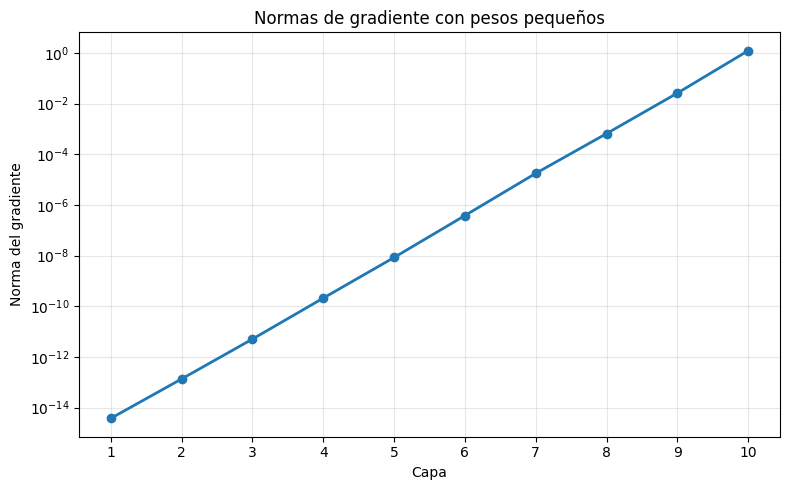

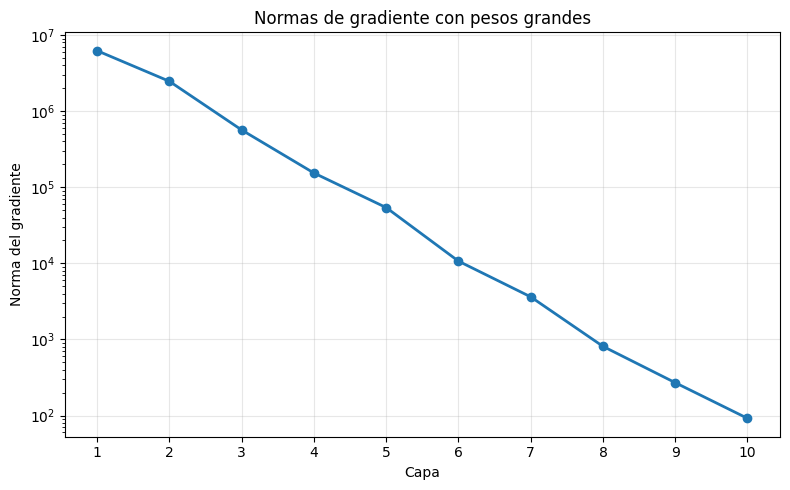

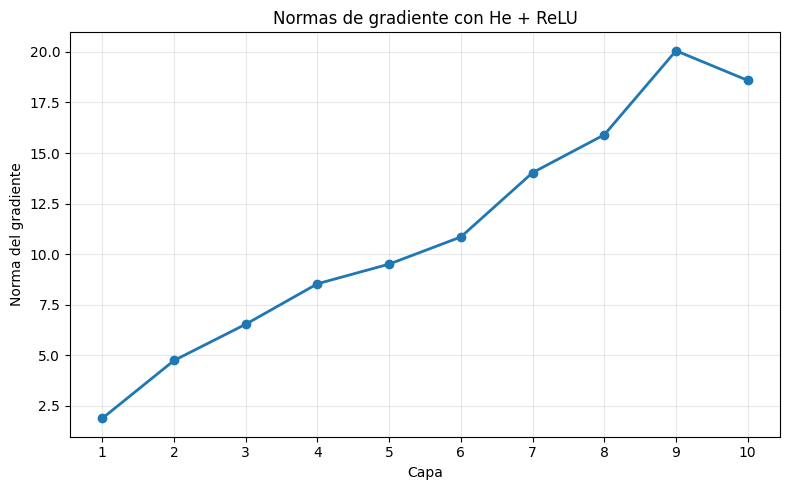

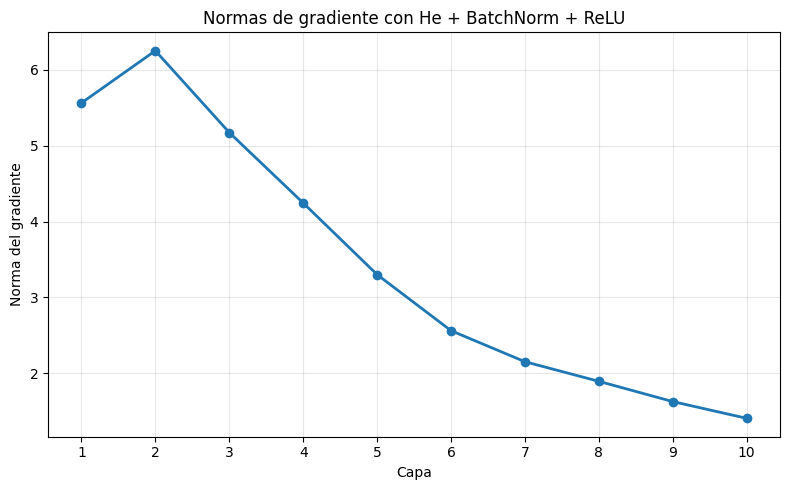

In [37]:
def grad_norms(grads, L):
    norms = []
    for l in range(1, L + 1):
        norms.append(np.linalg.norm(grads[f"dW{l}"]))
    return np.array(norms)

def graficar_desde_grads(grads, L, titulo, log_scale=False):
    capas = np.arange(1, L + 1)
    normas = grad_norms(grads, L)

    plt.figure(figsize=(8, 5))
    plt.plot(capas, normas, marker='o', linewidth=2)
    plt.xlabel("Capa")
    plt.ylabel("Norma del gradiente")
    plt.title(titulo)
    plt.xticks(capas)
    plt.grid(True, alpha=0.3)

    if log_scale:
        plt.yscale("log")

    plt.tight_layout()
    plt.show()

graficar_desde_grads(grads_small, L, "Normas de gradiente con pesos pequeños", log_scale=True)
graficar_desde_grads(grads_large, L, "Normas de gradiente con pesos grandes", log_scale=True)
graficar_desde_grads(grads_he, L, "Normas de gradiente con He + ReLU", log_scale=False)
graficar_desde_grads(grads_bn, L, "Normas de gradiente con He + BatchNorm + ReLU", log_scale=False)